# Data Collection, Understanding & Preparation
## Olist Brazilian E-Commerce · Reverse Logistics Analysis

**Pipeline của notebook này:**

```
1. Load Data          → Đọc 8 bảng CSV
2. Data Understanding → Cấu trúc, ER diagram, xem trước
3. EDA Sơ bộ          → shape, dtypes, describe, missing %, outlier detect   ← TRƯỚC cleaning
       ↓ phát hiện vấn đề
4. Data Cleaning      → Chuẩn hoá, xử lý missing, Winsorization
5. Feature Engineering→ Tạo biến mới
6. Build Table        → Join 8 bảng → 1 bảng tổng hợp
7. EDA Kiểm tra lại   → Verify sau cleaning                                  ← SAU cleaning
8. Export CSV         → olist_analytical_table.csv cho Bước 3 → 6
```

> Output duy nhất: `olist_analytical_table.csv` dùng chung cho Bước (SQL) · (Python) · (Viz) · (Regression)

## 0. Import thư viện

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Import thư viện thành công!")

Import thư viện thành công!


## 1. Đọc dữ liệu (Data Loading)

In [56]:
DATA_DIR = "datasets/"

df_orders         = pd.read_csv(DATA_DIR + "olist_orders_dataset.csv")
df_order_items    = pd.read_csv(DATA_DIR + "olist_order_items_dataset.csv")
df_order_reviews  = pd.read_csv(DATA_DIR + "olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv(DATA_DIR + "olist_order_payments_dataset.csv")
df_customers      = pd.read_csv(DATA_DIR + "olist_customers_dataset.csv")
df_products       = pd.read_csv(DATA_DIR + "olist_products_dataset.csv")
df_sellers        = pd.read_csv(DATA_DIR + "olist_sellers_dataset.csv")
df_category_trans = pd.read_csv(DATA_DIR + "product_category_name_translation.csv")

datasets = {
    "orders"              : df_orders,
    "order_items"         : df_order_items,
    "order_reviews"       : df_order_reviews,
    "order_payments"      : df_order_payments,
    "customers"           : df_customers,
    "products"            : df_products,
    "sellers"             : df_sellers,
    "category_translation": df_category_trans,
}

print("Đọc dữ liệu thành công!\n")
summary = pd.DataFrame(
    [(k, v.shape[0], v.shape[1]) for k, v in datasets.items()],
    columns=["Bảng", "Số dòng", "Số cột"]
)
summary["Số dòng"] = summary["Số dòng"].map("{:,}".format)
display(summary.set_index("Bảng"))

Đọc dữ liệu thành công!



,Số dòng,Số cột
Bảng,,
orders,"99,441",8
order_items,"112,650",7
order_reviews,"99,224",7
order_payments,"103,886",5
customers,"99,441",5
products,"32,951",9
sellers,"3,095",4
category_translation,71,2


## 2. Hiểu cấu trúc dữ liệu (Data Understanding)

### Lược đồ quan hệ (Entity-Relationship)

```
customers ──< orders ──< order_items >── products >── category_translation
                  │            │
                  │            └──< sellers
                  ├──< order_reviews
                  └──< order_payments
```

| Bảng trái | Khoá join | Bảng phải |
|-----------|-----------|-----------|
| orders | `customer_id` | customers |
| order_items | `order_id` | orders |
| order_reviews | `order_id` | orders |
| order_payments | `order_id` | orders |
| order_items | `product_id` | products |
| order_items | `seller_id` | sellers |
| products | `product_category_name` | category_translation |

In [57]:
for name, df in datasets.items():
    print(f"{'─'*60}")
    print(f"Bảng {name}  ({df.shape[0]:,} rows × {df.shape[1]} cols)")
    display(df.head(3))

────────────────────────────────────────────────────────────
Bảng orders  (99,441 rows × 8 cols)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


────────────────────────────────────────────────────────────
Bảng order_items  (112,650 rows × 7 cols)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87


────────────────────────────────────────────────────────────
Bảng order_reviews  (99,224 rows × 7 cols)


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00


────────────────────────────────────────────────────────────
Bảng sellers  (3,095 rows × 4 cols)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


────────────────────────────────────────────────────────────
Bảng category_translation  (71 rows × 2 cols)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


## 3. EDA Sơ bộ (Trước khi làm sạch)

>  **Tại sao EDA trước cleaning?**  
> EDA là bước "chẩn bệnh" — phải nhìn thấy vấn đề gốc trước khi chữa.  
> Nếu cleaning trước thì mất bằng chứng: không còn thấy outlier, missing, hay phân phối lệch ban đầu.

### 3.1 Tổng quan kiểu dữ liệu & Non-null (df.info)

In [58]:
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"Bảng {name}")
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"   {'Cột':<40} {'Dtype':<15} {'Non-Null':>10} {'Null %':>8}")
    print(f"   {'─'*40} {'─'*15} {'─'*10} {'─'*8}")
    for col in df.columns:
        non_null = df[col].notna().sum()
        null_pct = (df[col].isna().sum() / len(df) * 100)
        flag = " !" if null_pct > 0 else ""
        print(f"   {col:<40} {str(df[col].dtype):<15} {non_null:>10,} {null_pct:>7.1f}%{flag}")


Bảng orders
   Shape: 99,441 rows × 8 cols
   Cột                                      Dtype             Non-Null   Null %
   ──────────────────────────────────────── ─────────────── ────────── ────────
   order_id                                 object              99,441     0.0%
   customer_id                              object              99,441     0.0%
   order_status                             object              99,441     0.0%
   order_purchase_timestamp                 object              99,441     0.0%
   order_approved_at                        object              99,281     0.2% !
   order_delivered_carrier_date             object              97,658     1.8% !
   order_delivered_customer_date            object              96,476     3.0% !
   order_estimated_delivery_date            object              99,441     0.0%

Bảng order_items
   Shape: 112,650 rows × 7 cols
   Cột                                      Dtype             Non-Null   Null %
   ─────────────────

### 3.2 Thống kê mô tả từng bảng (df.describe)

In [59]:
for name, df in datasets.items():
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if num_cols:
        print(f"\n{'='*60}")
        print(f" {name} — thống kê các cột số ({len(num_cols)} cột):")
        display(df[num_cols].describe().T.round(2))
    else:
        print(f"\nBảng {name} — không có cột số")


Bảng orders — không có cột số

 order_items — thống kê các cột số (3 cột):


,count,mean,std,min,25%,50%,75%,max
order_item_id,"112,650.00",1.20,0.71,1.00,1.00,1.00,1.00,21.00
price,"112,650.00",120.65,183.63,0.85,39.90,74.99,134.90,"6,735.00"
freight_value,"112,650.00",19.99,15.81,0.00,13.08,16.26,21.15,409.68



 order_reviews — thống kê các cột số (1 cột):


,count,mean,std,min,25%,50%,75%,max
review_score,"99,224.00",4.09,1.35,1.00,4.00,5.00,5.00,5.00



 order_payments — thống kê các cột số (3 cột):


...


 products — thống kê các cột số (7 cột):


,count,mean,std,min,25%,50%,75%,max
product_name_lenght,"32,341.00",48.48,10.25,5.00,42.00,51.00,57.00,76.00
product_description_lenght,"32,341.00",771.50,635.12,4.00,339.00,595.00,972.00,"3,992.00"
product_photos_qty,"32,341.00",2.19,1.74,1.00,1.00,1.00,3.00,20.00
product_weight_g,"32,949.00","2,276.47","4,282.04",0.00,300.00,700.00,"1,900.00","40,425.00"
product_length_cm,"32,949.00",30.82,16.91,7.00,18.00,25.00,38.00,105.00
product_height_cm,"32,949.00",16.94,13.64,2.00,8.00,13.00,21.00,105.00
product_width_cm,"32,949.00",23.20,12.08,6.00,15.00,20.00,30.00,118.00



 sellers — thống kê các cột số (1 cột):


,count,mean,std,min,25%,50%,75%,max
seller_zip_code_prefix,"3,095.00","32,291.06","32,713.45","1,001.00","7,093.50","14,940.00","64,552.50","99,730.00"



Bảng category_translation — không có cột số


### 3.3 Phân phối biến categorical quan trọng

In [60]:
print("── order_status ─────────────────────────────────────")
print(df_orders["order_status"].value_counts())

print("\n── payment_type ────────────────────────────────────")
print(df_order_payments["payment_type"].value_counts())

print("\n── review_score ────────────────────────────────────")
print(df_order_reviews["review_score"].value_counts().sort_index())

print("\n── customer_state (Top 10) ─────────────────────────")
print(df_customers["customer_state"].value_counts().head(10))

print("\n── seller_state (Top 10) ───────────────────────────")
print(df_sellers["seller_state"].value_counts().head(10))

print("\n── product_category (Top 10) ───────────────────────")
print(df_products["product_category_name"].value_counts().head(10))

── order_status ─────────────────────────────────────
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

── payment_type ────────────────────────────────────
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

── review_score ────────────────────────────────────
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

── customer_state (Top 10) ─────────────────────────
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

── seller_state (Top 10) ───────────────────────────
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
N

### 3.4 Missing Values — toàn bộ các bảng

In [61]:
def missing_report(df, name):
    miss   = df.isnull().sum()
    pct    = (miss / len(df) * 100).round(2)
    result = pd.DataFrame({"Missing Count": miss, "Missing %": pct})
    result = result[result["Missing Count"] > 0].sort_values("Missing %", ascending=False)
    if result.empty:
        print(f"   [{name}] Không có missing values")
    else:
        print(f"    [{name}] — {len(result)} cột có missing:")
        display(result)

print("=" * 60)
for name, df in datasets.items():
    missing_report(df, name)
    print()

    [orders] — 3 cột có missing:


,Missing Count,Missing %
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



   [order_items] Không có missing values

    [order_reviews] — 2 cột có missing:


,Missing Count,Missing %
review_comment_title,87656,88.34
review_comment_message,58247,58.70



   [order_payments] Không có missing values

   [customers] Không có missing values

    [products] — 8 cột có missing:


,Missing Count,Missing %
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01



   [sellers] Không có missing values

   [category_translation] Không có missing values



### 3.5 Duplicate Values

In [62]:
dup_cfg = {
    "orders"              : ["order_id"],
    "order_items"         : ["order_id", "order_item_id"],
    "order_reviews"       : ["review_id"],
    "order_payments"      : ["order_id", "payment_sequential"],
    "customers"           : ["customer_id"],
    "products"            : ["product_id"],
    "sellers"             : ["seller_id"],
    "category_translation": ["product_category_name"],
}
rows = []
for name, df in datasets.items():
    pk = dup_cfg[name]
    rows.append({
        "Bảng"            : name,
        "Trùng toàn dòng" : df.duplicated().sum(),
        "Trùng PK"        : df.duplicated(subset=pk).sum(),
        "PK columns"      : str(pk),
    })
display(pd.DataFrame(rows).set_index("Bảng"))

,Trùng toàn dòng,Trùng PK,PK columns
Bảng,,,
orders,0,0,['order_id']
order_items,0,0,"['order_id', 'order_item_id']"
order_reviews,0,814,['review_id']
order_payments,0,0,"['order_id', 'payment_sequential']"
customers,0,0,['customer_id']
products,0,0,['product_id']
sellers,0,0,['seller_id']
category_translation,0,0,['product_category_name']


### 3.6 Referential Integrity (Khoá ngoại)

In [63]:
def check_integrity(l_df, l_key, r_df, r_key, label):
    l_keys = set(l_df[l_key].dropna())
    r_keys = set(r_df[r_key].dropna())
    orphan = len(l_keys - r_keys)
    status = "✅" if orphan == 0 else "⚠️ "
    print(f"  {status} {label}")
    print(f"     left={len(l_keys):,}  right={len(r_keys):,}  orphan={orphan:,}")

print("Kiểm tra referential integrity:")
check_integrity(df_orders,        "customer_id", df_customers, "customer_id",  "orders → customers")
check_integrity(df_order_items,   "order_id",    df_orders,    "order_id",     "order_items → orders")
check_integrity(df_order_reviews, "order_id",    df_orders,    "order_id",     "order_reviews → orders")
check_integrity(df_order_payments,"order_id",    df_orders,    "order_id",     "order_payments → orders")
check_integrity(df_order_items,   "product_id",  df_products,  "product_id",   "order_items → products")
check_integrity(df_order_items,   "seller_id",   df_sellers,   "seller_id",    "order_items → sellers")

Kiểm tra referential integrity:
  ✅ orders → customers
     left=99,441  right=99,441  orphan=0
  ✅ order_items → orders
     left=98,666  right=99,441  orphan=0
  ✅ order_reviews → orders
     left=98,673  right=99,441  orphan=0
  ✅ order_payments → orders
     left=99,440  right=99,441  orphan=0
  ✅ order_items → products
     left=32,951  right=32,951  orphan=0
  ✅ order_items → sellers
     left=3,095  right=3,095  orphan=0


### 3.7 Phát hiện Outliers — Visualize TRƯỚC khi xử lý

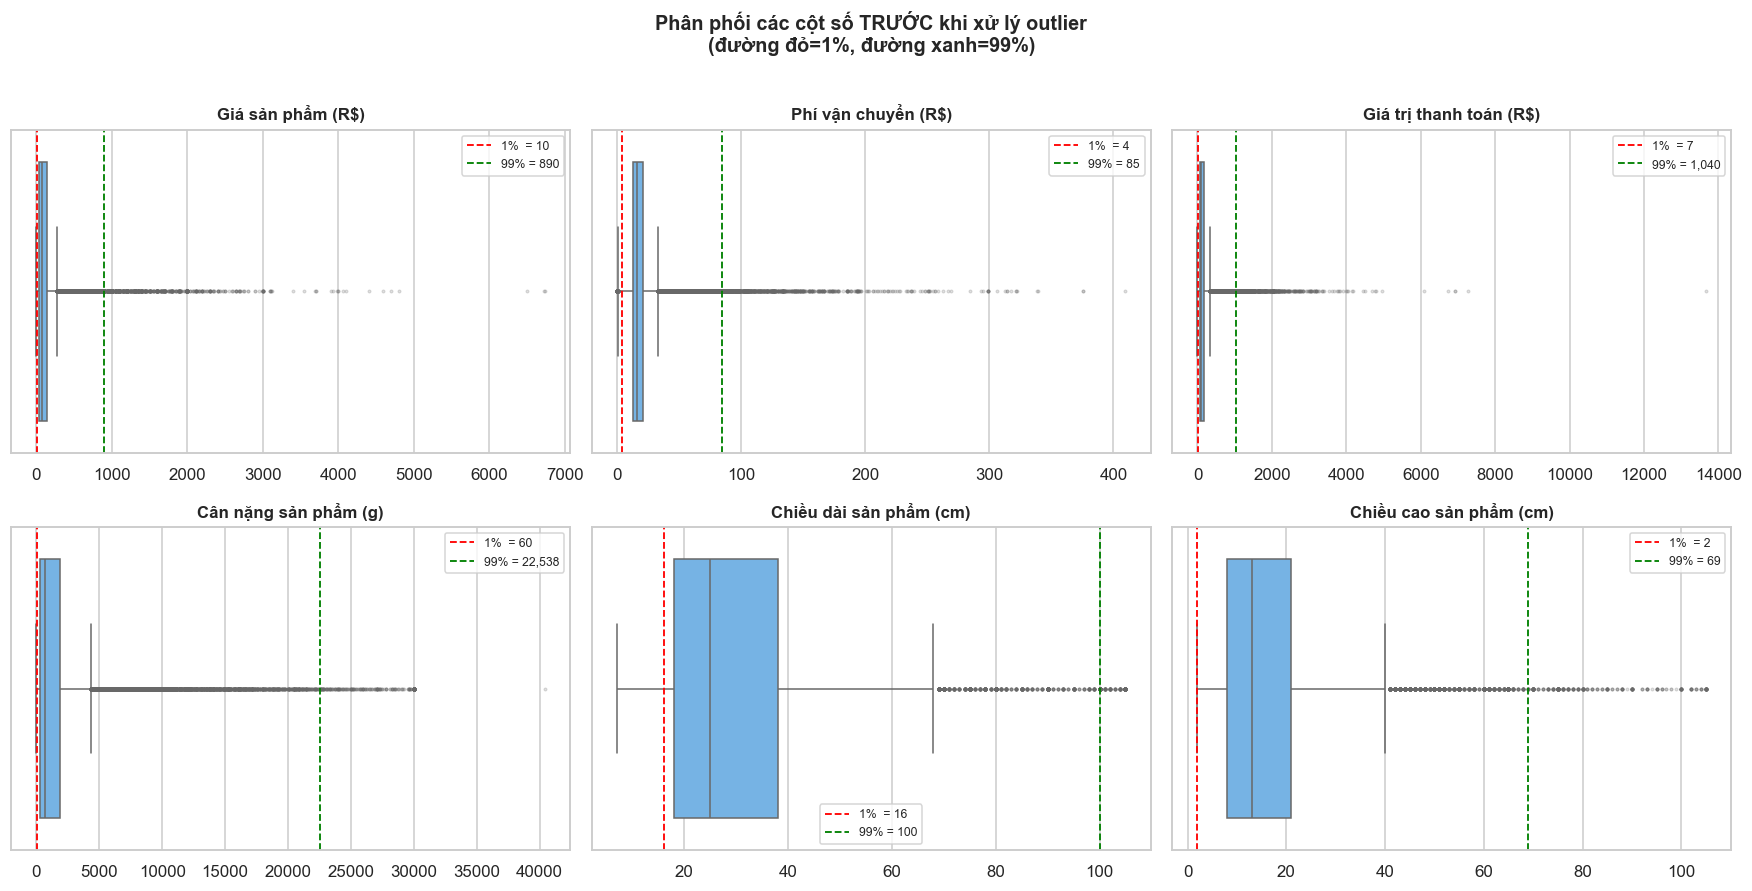

In [64]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

plot_cfg = [
    (df_order_items,    "price",            "Giá sản phẩm (R$)"),
    (df_order_items,    "freight_value",    "Phí vận chuyển (R$)"),
    (df_order_payments, "payment_value",    "Giá trị thanh toán (R$)"),
    (df_products,       "product_weight_g", "Cân nặng sản phẩm (g)"),
    (df_products,       "product_length_cm","Chiều dài sản phẩm (cm)"),
    (df_products,       "product_height_cm","Chiều cao sản phẩm (cm)"),
]

for i, (df, col, title) in enumerate(plot_cfg):
    ax = axes[i]
    sns.boxplot(x=df[col], ax=ax, color="#64B5F6",
                flierprops=dict(marker=".", alpha=0.3, markersize=3))
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    ax.axvline(p1,  color="red",   linestyle="--", linewidth=1.2, label=f"1%  = {p1:,.0f}")
    ax.axvline(p99, color="green", linestyle="--", linewidth=1.2, label=f"99% = {p99:,.0f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.suptitle("Phân phối các cột số TRƯỚC khi xử lý outlier\n(đường đỏ=1%, đường xanh=99%)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.8 Bảng thống kê ngưỡng Outlier

In [65]:
def outlier_stats(df, col, lo_pct=1, hi_pct=99):
    lo   = df[col].quantile(lo_pct / 100)
    hi   = df[col].quantile(hi_pct / 100)
    n_lo = (df[col] < lo).sum()
    n_hi = (df[col] > hi).sum()
    return {
        "Cột"              : col,
        f"Ngưỡng {lo_pct}%": f"{lo:,.2f}",
        f"Ngưỡng {hi_pct}%": f"{hi:,.2f}",
        f"Dưới {lo_pct}%"  : n_lo,
        f"Trên {hi_pct}%"  : n_hi,
        "Tổng outlier"     : n_lo + n_hi,
        "Tỉ lệ (%)"        : f"{(n_lo + n_hi) / len(df) * 100:.1f}",
    }

stats = [
    outlier_stats(df_order_items,    "price"),
    outlier_stats(df_order_items,    "freight_value"),
    outlier_stats(df_order_payments, "payment_value"),
    outlier_stats(df_products,       "product_weight_g"),
    outlier_stats(df_products,       "product_length_cm"),
    outlier_stats(df_products,       "product_height_cm"),
    outlier_stats(df_products,       "product_width_cm"),
]
display(pd.DataFrame(stats).set_index("Cột"))

print("\nChien luoc: Winsorization (cap 1%%-99%%)")
print("Ly do KHONG dung IQR xoa dong:")
print("  - Ti le outlier 5-14%% -- qua lon de xoa, mat nhieu thong tin")
print("  - Hang xa xi la outlier HOP LE trong e-commerce")
print("  - Winsorize giu nguyen so dong, keo gia tri cuc bien ve nguong an toan")

,Ngưỡng 1%,Ngưỡng 99%,Dưới 1%,Trên 99%,Tổng outlier,Tỉ lệ (%)
Cột,,,,,,
price,9.99,890.00,1080,1117,2197,2.0
freight_value,4.42,84.52,1127,1124,2251,2.0
payment_value,6.69,"1,039.92",1038,1039,2077,2.0
product_weight_g,60.00,"22,538.00",327,330,657,2.0
product_length_cm,16.00,100.00,147,214,361,1.1
product_height_cm,2.00,69.00,0,323,323,1.0
product_width_cm,11.00,63.00,53,324,377,1.1



Chien luoc: Winsorization (cap 1%%-99%%)
Ly do KHONG dung IQR xoa dong:
  - Ti le outlier 5-14%% -- qua lon de xoa, mat nhieu thong tin
  - Hang xa xi la outlier HOP LE trong e-commerce
  - Winsorize giu nguyen so dong, keo gia tri cuc bien ve nguong an toan


## 4. Làm sạch dữ liệu (Data Cleaning)

> Dựa trên kết quả EDA sơ bộ ở Bước 3, tiến hành xử lý theo thứ tự:
> 1. Chuyển đổi kiểu dữ liệu
> 2. Chuẩn hoá chuỗi
> 3. Xử lý Missing Values (chỉ loại "dữ liệu xấu")
> 4. Winsorization outliers

### 4.1 Chuyển đổi kiểu dữ liệu Datetime

In [66]:
dt_order_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in dt_order_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

df_order_items["shipping_limit_date"]          = pd.to_datetime(df_order_items["shipping_limit_date"],          errors="coerce")
df_order_reviews["review_creation_date"]       = pd.to_datetime(df_order_reviews["review_creation_date"],       errors="coerce")
df_order_reviews["review_answer_timestamp"]    = pd.to_datetime(df_order_reviews["review_answer_timestamp"],    errors="coerce")

print("✅ Datetime conversion hoàn tất")
print(df_orders[dt_order_cols].dtypes)

✅ Datetime conversion hoàn tất
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


### 4.2 Chuẩn hoá chuỗi (String Normalization)

In [67]:
df_orders["order_status"]                      = df_orders["order_status"].str.lower().str.strip()
df_order_payments["payment_type"]              = df_order_payments["payment_type"].str.lower().str.strip()
df_customers["customer_state"]                 = df_customers["customer_state"].str.upper().str.strip()
df_customers["customer_city"]                  = df_customers["customer_city"].str.lower().str.strip()
df_sellers["seller_state"]                     = df_sellers["seller_state"].str.upper().str.strip()
df_sellers["seller_city"]                      = df_sellers["seller_city"].str.lower().str.strip()
df_products["product_category_name"]           = df_products["product_category_name"].str.lower().str.strip()
df_category_trans["product_category_name"]     = df_category_trans["product_category_name"].str.lower().str.strip()
df_category_trans["product_category_name_english"] = df_category_trans["product_category_name_english"].str.lower().str.strip()

print("✅ String normalization hoàn tất")
print("\norder_status sau chuẩn hoá:")
print(df_orders["order_status"].value_counts())

✅ String normalization hoàn tất

order_status sau chuẩn hoá:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


### 4.3 Xử lý Missing Values (chỉ loại dữ liệu xấu)

In [68]:
# Products: cột số → điền trung vị
num_prod_cols = [
    "product_name_lenght", "product_description_lenght", "product_photos_qty",
    "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"
]
for col in num_prod_cols:
    med = df_products[col].median()
    df_products[col].fillna(med, inplace=True)

# Products: category thiếu → 'unknown'
df_products["product_category_name"].fillna("unknown", inplace=True)

# Reviews: text → chuỗi rỗng
df_order_reviews["review_comment_title"].fillna("",   inplace=True)
df_order_reviews["review_comment_message"].fillna("", inplace=True)

# ĐỂ NGUYÊN: missing datetime trong orders (đơn chưa giao / bị huỷ)
# → sẽ tạo NaN ở feature engineering, xử lý downstream ở Bước 4/6

print("✅ Missing values đã xử lý")
print("\nKiểm tra lại products — không còn missing:")
print(df_products[num_prod_cols].isnull().sum().to_string())

✅ Missing values đã xử lý

Kiểm tra lại products — không còn missing:
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0


### 4.4 Xử lý Outliers — Winsorization (Cap 1%–99%)

**Chiến lược Winsorization:** thay vì xoá dòng, kéo giá trị cực biên về ngưỡng 1% và 99%.  
Đồng thời tạo cột flag `is_outlier_*` để các bước phân tích sau có thể lọc riêng nếu cần.

In [69]:
def winsorize_col(df, col, lo_pct=1, hi_pct=99, flag=True):
    lo = df[col].quantile(lo_pct / 100)
    hi = df[col].quantile(hi_pct / 100)
    if flag:
        df[f"is_outlier_{col}"] = ((df[col] < lo) | (df[col] > hi)).astype(int)
    df[col] = df[col].clip(lower=lo, upper=hi)
    flagged = df[f"is_outlier_{col}"].sum() if flag else "-"
    print(f"  ✂️  {col:<25s} capped [{lo:>10,.2f}, {hi:>10,.2f}]  flagged={flagged}")

print("── order_items ──────────────────────────────────────")
winsorize_col(df_order_items, "price")
winsorize_col(df_order_items, "freight_value")

print("── order_payments ───────────────────────────────────")
winsorize_col(df_order_payments, "payment_value")

print("── products (không flag — dùng gián tiếp) ───────────")
winsorize_col(df_products, "product_weight_g",   flag=False)
winsorize_col(df_products, "product_length_cm",  flag=False)
winsorize_col(df_products, "product_height_cm",  flag=False)
winsorize_col(df_products, "product_width_cm",   flag=False)

print("\n✅ Winsorization hoàn tất!")

── order_items ──────────────────────────────────────
  ✂️  price                     capped [      9.99,     890.00]  flagged=2197
  ✂️  freight_value             capped [      4.42,      84.52]  flagged=2251
── order_payments ───────────────────────────────────
  ✂️  payment_value             capped [      6.69,   1,039.92]  flagged=2077
── products (không flag — dùng gián tiếp) ───────────
  ✂️  product_weight_g          capped [     60.00,  22,537.50]  flagged=-
  ✂️  product_length_cm         capped [     16.00,     100.00]  flagged=-
  ✂️  product_height_cm         capped [      2.00,      69.00]  flagged=-
  ✂️  product_width_cm          capped [     11.00,      63.00]  flagged=-

✅ Winsorization hoàn tất!


### 4.5 Visualize phân phối SAU Winsorization — so sánh với TRƯỚC

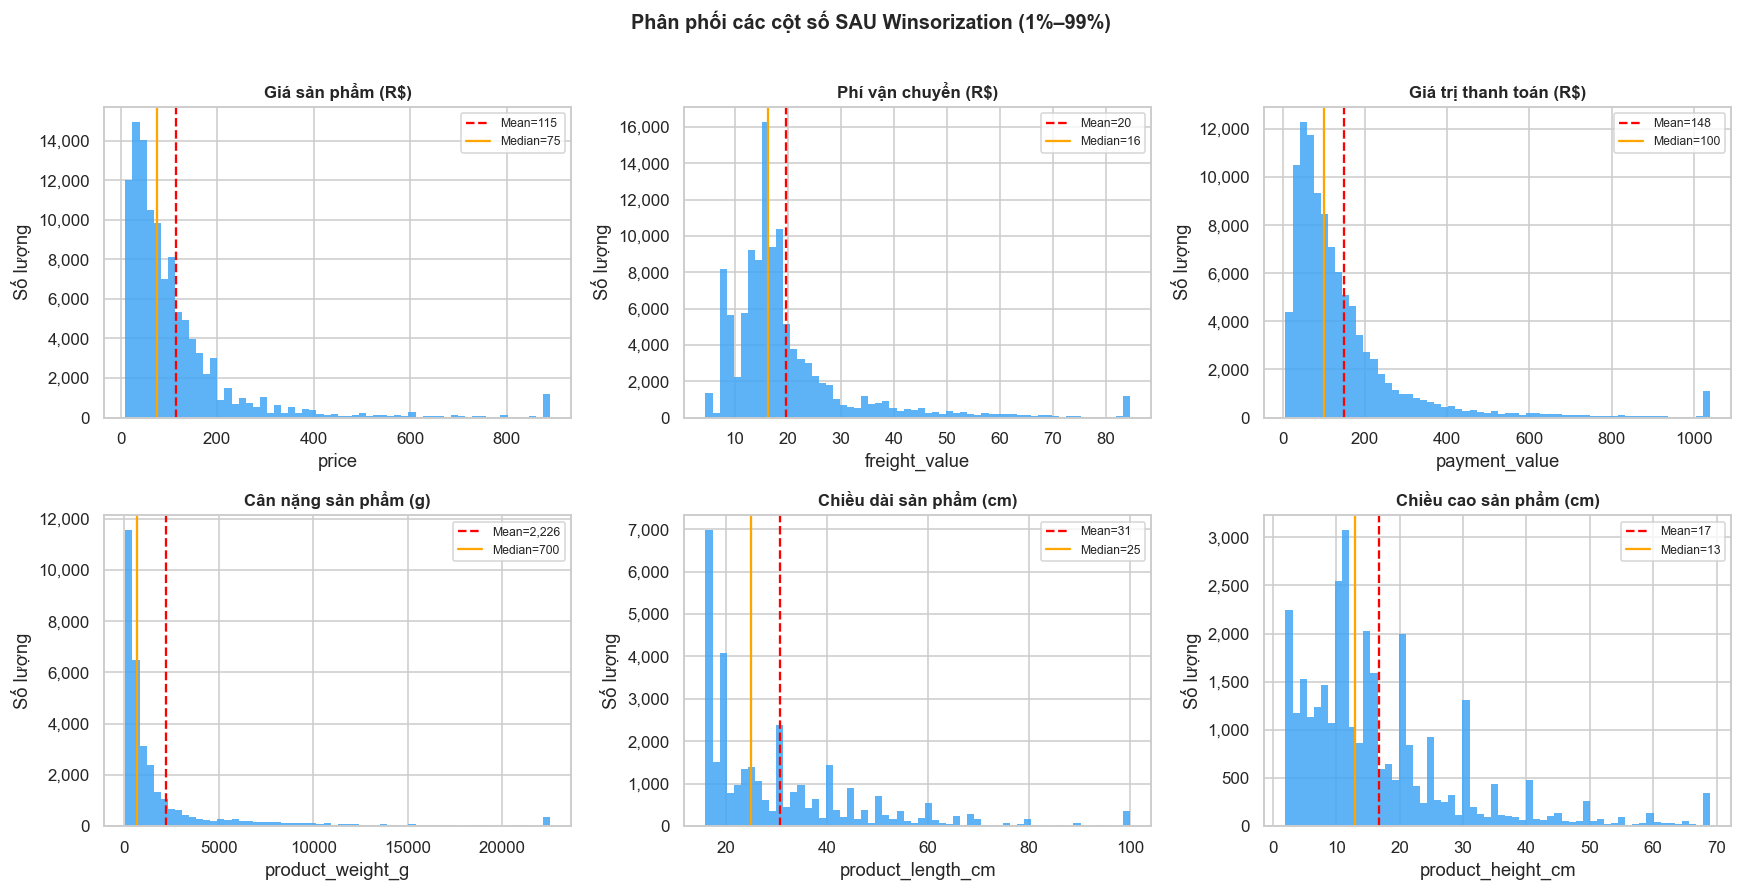

Nhan xet sau Winsorize:
  - Tat ca phan phoi deu right-skewed (lech phai)
  - Mean > Median o tat ca cot -> xac nhan phan phoi lech phai
  - Spike nho o cuoi truc X = hieu ung winsorize dang hoat dong dung


In [70]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

after_cfg = [
    (df_order_items,    "price",            "Giá sản phẩm (R$)"),
    (df_order_items,    "freight_value",    "Phí vận chuyển (R$)"),
    (df_order_payments, "payment_value",    "Giá trị thanh toán (R$)"),
    (df_products,       "product_weight_g", "Cân nặng sản phẩm (g)"),
    (df_products,       "product_length_cm","Chiều dài sản phẩm (cm)"),
    (df_products,       "product_height_cm","Chiều cao sản phẩm (cm)"),
]

for i, (df, col, title) in enumerate(after_cfg):
    ax    = axes[i]
    data  = df[col].dropna()
    ax.hist(data, bins=60, color="#42A5F5", edgecolor="none", alpha=0.85)
    ax.axvline(data.mean(),   color="red",    linestyle="--", linewidth=1.5,
               label=f"Mean={data.mean():,.0f}")
    ax.axvline(data.median(), color="orange", linestyle="-",  linewidth=1.5,
               label=f"Median={data.median():,.0f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Số lượng")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Phân phối các cột số SAU Winsorization (1%–99%)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Nhan xet sau Winsorize:")
print("  - Tat ca phan phoi deu right-skewed (lech phai)")
print("  - Mean > Median o tat ca cot -> xac nhan phan phoi lech phai")
print("  - Spike nho o cuoi truc X = hieu ung winsorize dang hoat dong dung")

## 5. Feature Engineering

In [71]:
# ── Thời gian đặt hàng ───────────────────────────────────
df_orders["purchase_year"]    = df_orders["order_purchase_timestamp"].dt.year
df_orders["purchase_month"]   = df_orders["order_purchase_timestamp"].dt.month
df_orders["purchase_quarter"] = df_orders["order_purchase_timestamp"].dt.quarter
df_orders["purchase_dow"]     = df_orders["order_purchase_timestamp"].dt.dayofweek  # 0=Mon

# ── Thời gian giao hàng (ngày) ───────────────────────────
df_orders["actual_delivery_days"] = (
    df_orders["order_delivered_customer_date"] -
    df_orders["order_purchase_timestamp"]
).dt.days

df_orders["estimated_delivery_days"] = (
    df_orders["order_estimated_delivery_date"] -
    df_orders["order_purchase_timestamp"]
).dt.days

# ── Giao hàng trễ ────────────────────────────────────────
df_orders["delay_days"] = (
    df_orders["actual_delivery_days"] -
    df_orders["estimated_delivery_days"]
)

df_orders["is_late_delivery"] = (
    df_orders["delay_days"] > 0
).astype("Int8")

# ── Trạng thái giao hàng ─────────────────────────────────
# 1 = delivered, 0 = not delivered
df_orders["is_delivered"] = (
    df_orders["order_delivered_customer_date"]
    .notnull()
    .astype("Int8")
)

# ── Hiệu quả giao hàng ───────────────────────────────────
# >0 = giao sớm hơn dự kiến
# <0 = giao trễ hơn dự kiến
df_orders["delivery_efficiency"] = (
    df_orders["estimated_delivery_days"] -
    df_orders["actual_delivery_days"]
)

# ── Proxy khoảng cách địa lý (RQ3) ───────────────────────
# Feature này tạo SAU KHI join seller_state và customer_state
# Ví dụ:
#
# df["interstate_shipping"] = (
#     df["seller_state"] != df["customer_state"]
# ).astype("Int8")

# ── order_items: tổng giá trị đơn ────────────────────────
df_order_items["total_item_value"] = (
    df_order_items["price"] +
    df_order_items["freight_value"]
)

# ── Tỷ lệ phí vận chuyển / giá sản phẩm ──────────────────
df_order_items["freight_price_ratio"] = (
    df_order_items["freight_value"] /
    df_order_items["price"]
)

# ── Product volume (RQ2) ─────────────────────────────────
df_products["product_volume_cm3"] = (
    df_products["product_length_cm"] *
    df_products["product_height_cm"] *
    df_products["product_width_cm"]
)

print("✅ Feature engineering hoàn tất")

# ── Summary statistics ───────────────────────────────────
new_feats_orders = [
    "purchase_year",
    "purchase_month",
    "purchase_quarter",
    "purchase_dow",
    "actual_delivery_days",
    "estimated_delivery_days",
    "delay_days",
    "is_late_delivery",
    "is_delivered",
    "delivery_efficiency"
]

display(
    df_orders[new_feats_orders]
    .describe()
    .T
    .round(2)
)

display(
    df_order_items[[
        "total_item_value",
        "freight_price_ratio"
    ]]
    .describe()
    .T
    .round(2)
)

display(
    df_products[[
        "product_volume_cm3"
    ]]
    .describe()
    .T
    .round(2)
)

✅ Feature engineering hoàn tất


,count,mean,std,min,25%,50%,75%,max
purchase_year,"99,441.00","2,017.54",0.51,"2,016.00","2,017.00","2,018.00","2,018.00","2,018.00"
purchase_month,"99,441.00",6.03,3.23,1.00,3.00,6.00,8.00,12.00
purchase_quarter,"99,441.00",2.36,1.06,1.00,1.00,2.00,3.00,4.00
purchase_dow,"99,441.00",2.76,1.97,0.00,1.00,3.00,4.00,6.00
actual_delivery_days,"96,476.00",12.09,9.55,0.00,6.00,10.00,15.00,209.00
estimated_delivery_days,"99,441.00",23.40,8.83,1.00,18.00,23.00,28.00,155.00
delay_days,"96,476.00",-11.28,10.19,-146.00,-16.00,-12.00,-7.00,189.00
is_late_delivery,"99,441.00",0.07,0.26,0.00,0.00,0.00,0.00,1.00
is_delivered,"99,441.00",0.97,0.17,0.00,1.00,1.00,1.00,1.00
delivery_efficiency,"96,476.00",11.28,10.19,-189.00,7.00,12.00,16.00,146.00


,count,mean,std,min,25%,50%,75%,max
total_item_value,"112,650.00",134.94,142.41,14.41,55.28,92.41,157.90,974.52
freight_price_ratio,"112,650.00",0.31,0.29,0.00,0.13,0.23,0.39,8.46


,count,mean,std,min,25%,50%,75%,max
product_volume_cm3,"32,951.00","16,279.59","25,938.09",352.00,"2,880.00","6,859.00","18,432.00","288,000.00"


## 6. Xây dựng bảng phân tích tổng hợp (Build Analytical Table)

### 6.1 Aggregate order_items

In [72]:
items_agg = df_order_items.groupby("order_id").agg(
    total_items         = ("order_item_id",         "count"),
    total_price         = ("price",                 "sum"),
    total_freight       = ("freight_value",         "sum"),
    total_order_value   = ("total_item_value",      "sum"),
    avg_item_price      = ("price",                 "mean"),
    unique_sellers      = ("seller_id",             "nunique"),
    has_outlier_price   = ("is_outlier_price",      "max"),
    has_outlier_freight = ("is_outlier_freight_value","max"),
).reset_index()
print(f"items_agg: {items_agg.shape}")
display(items_agg.head(3))

items_agg: (98666, 9)


,order_id,total_items,total_price,total_freight,total_order_value,avg_item_price,unique_sellers,has_outlier_price,has_outlier_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19,58.90,1,0,0
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83,239.90,1,0,0
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87,199.00,1,0,0


### 6.2 Aggregate order_payments

In [73]:
payments_agg = df_order_payments.groupby("order_id").agg(
    total_payment_value = ("payment_value",        "sum"),
    max_installments    = ("payment_installments", "max"),
    payment_type_count  = ("payment_type",         "nunique"),
    has_outlier_payment = ("is_outlier_payment_value", "max"),
).reset_index()

primary_pmt = (
    df_order_payments
    .sort_values("payment_value", ascending=False)
    .drop_duplicates(subset=["order_id"])
    [["order_id", "payment_type"]]
    .rename(columns={"payment_type": "primary_payment_type"})
)
payments_agg = payments_agg.merge(primary_pmt, on="order_id", how="left")
print(f"payments_agg: {payments_agg.shape}")
display(payments_agg.head(3))

payments_agg: (99440, 6)


,order_id,total_payment_value,max_installments,payment_type_count,has_outlier_payment,primary_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,0,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,0,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,0,credit_card


### 6.3 Aggregate order_reviews

In [74]:
reviews_agg = df_order_reviews.groupby("order_id").agg(
    avg_review_score = ("review_score", "mean"),
    review_count     = ("review_id",    "count"),
    has_comment      = ("review_comment_message",
                        lambda x: int(x.str.len().max() > 0)),
).reset_index()
reviews_agg["avg_review_score"] = reviews_agg["avg_review_score"].round(2)
print(f"reviews_agg: {reviews_agg.shape}")
display(reviews_agg.head(3))

reviews_agg: (98673, 4)


,order_id,avg_review_score,review_count,has_comment
0,00010242fe8c5a6d1ba2dd792cb16214,5.00,1,1
1,00018f77f2f0320c557190d7a144bdd3,4.00,1,0
2,000229ec398224ef6ca0657da4fc703e,5.00,1,1


### 6.4 Join tất cả bảng

In [75]:
df_anal = df_orders.copy()

# Customers
df_anal = df_anal.merge(
    df_customers[["customer_id","customer_unique_id","customer_city","customer_state"]],
    on="customer_id", how="left")

# Aggregated tables
df_anal = df_anal.merge(items_agg,    on="order_id", how="left")
df_anal = df_anal.merge(payments_agg, on="order_id", how="left")
df_anal = df_anal.merge(reviews_agg,  on="order_id", how="left")

# Sản phẩm & seller chính (order_item_id = 1)
first_item = df_order_items[df_order_items["order_item_id"] == 1][
    ["order_id","product_id","seller_id"]].copy()

products_cat = df_products.merge(df_category_trans, on="product_category_name", how="left")
products_cat["product_category_name_english"] = (
    products_cat["product_category_name_english"]
    .fillna(products_cat["product_category_name"]))

first_item = first_item.merge(
    products_cat[["product_id","product_category_name","product_category_name_english",
                  "product_weight_g","product_length_cm","product_height_cm","product_width_cm"]],
    on="product_id", how="left")
first_item = first_item.merge(
    df_sellers[["seller_id","seller_city","seller_state"]],
    on="seller_id", how="left")

df_anal = df_anal.merge(first_item, on="order_id", how="left")
print(f"✅ Bảng tổng hợp: {df_anal.shape[0]:,} rows × {df_anal.shape[1]} cols")

✅ Bảng tổng hợp: 99,441 rows × 47 cols


### 6.5 Hậu xử lý & thêm feature địa lý

In [76]:
# Flag đơn có review
df_anal["has_review"] = df_anal["order_id"].isin(reviews_agg["order_id"]).astype(int)

# RQ3: proxy khoảng cách địa lý
df_anal["same_state"] = (
    df_anal["customer_state"] == df_anal["seller_state"]
).astype("Int8")

# Sắp xếp cột hợp lý
front_cols = [
    "order_id","customer_id","customer_unique_id","customer_city","customer_state",
    "order_status",
    "order_purchase_timestamp","order_approved_at",
    "order_delivered_carrier_date","order_delivered_customer_date",
    "order_estimated_delivery_date",
    "purchase_year","purchase_month","purchase_quarter","purchase_dow",
    "actual_delivery_days","estimated_delivery_days","delay_days","is_late_delivery",
    "total_items","total_price","total_freight","total_order_value","avg_item_price",
    "unique_sellers","has_outlier_price","has_outlier_freight",
    "total_payment_value","max_installments","payment_type_count",
    "primary_payment_type","has_outlier_payment",
    "avg_review_score","review_count","has_comment","has_review",
    "product_id","product_category_name","product_category_name_english",
    "product_weight_g","product_length_cm","product_height_cm","product_width_cm",
    "seller_id","seller_city","seller_state","same_state",
]
front_cols = [c for c in front_cols if c in df_anal.columns]
df_anal = df_anal[front_cols + [c for c in df_anal.columns if c not in front_cols]]

print(f"✅ Bảng phân tích hoàn chỉnh: {df_anal.shape[0]:,} rows × {df_anal.shape[1]} cols")
display(df_anal.head(3))

✅ Bảng phân tích hoàn chỉnh: 99,441 rows × 49 cols


,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_quarter,purchase_dow,actual_delivery_days,estimated_delivery_days,delay_days,is_late_delivery,total_items,total_price,total_freight,total_order_value,avg_item_price,unique_sellers,has_outlier_price,has_outlier_freight,total_payment_value,max_installments,payment_type_count,primary_payment_type,has_outlier_payment,avg_review_score,review_count,has_comment,has_review,product_id,product_category_name,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state,same_state,is_delivered,delivery_efficiency
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,4,0,8.00,15,-7.00,0,1.00,29.99,8.72,38.71,29.99,1.00,0.00,0.00,43.40,1.00,2.00,voucher,1.00,4.00,1.00,1.00,1,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares,500.00,19.00,8.00,13.00,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,1,1,7.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,3,1,13.00,19,-6.00,0,1.00,118.70,22.76,141.46,118.70,1.00,0.00,0.00,141.46,1.00,1.00,boleto,0.00,4.00,1.00,1.00,1,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery,400.00,19.00,13.00,19.00,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,0,1,6.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,3,2,9.00,26,-17.00,0,1.00,159.90,19.22,179.12,159.90,1.00,0.00,0.00,179.12,3.00,1.00,credit_card,0.00,5.00,1.00,0.00,1,aa4383b373c6aca5d8797843e5594415,automotivo,auto,420.00,24.00,19.00,21.00,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,0,1,17.00


## 7. EDA Kiểm tra lại (Sau khi làm sạch)

> Mục tiêu: xác nhận rằng data sau cleaning đúng như kỳ vọng.  
> So sánh với EDA sơ bộ ở Bước 3 để thấy rõ tác động của cleaning.

### 7.1 Thống kê mô tả bảng tổng hợp

In [77]:
key_cols = [
    "total_price","total_freight","total_order_value","avg_item_price",
    "total_payment_value","max_installments",
    "actual_delivery_days","delay_days","avg_review_score",
]
print("Thống kê mô tả các cột số chính (sau cleaning + winsorize):")
display(df_anal[key_cols].describe().T.round(2))

Thống kê mô tả các cột số chính (sau cleaning + winsorize):


,count,mean,std,min,25%,50%,75%,max
total_price,"98,666.00",131.64,159.21,9.99,45.90,86.90,149.90,"7,120.00"
total_freight,"98,666.00",22.42,18.11,4.42,13.85,17.18,24.06,626.64
total_order_value,"98,666.00",154.06,168.38,17.38,62.00,105.30,176.86,"7,344.08"
avg_item_price,"98,666.00",120.00,140.65,9.99,41.99,79.00,139.90,890.00
total_payment_value,"99,440.00",154.63,165.57,6.69,62.01,105.37,176.99,"2,079.83"
max_installments,"99,440.00",2.93,2.72,0.00,1.00,2.00,4.00,24.00
actual_delivery_days,"96,476.00",12.09,9.55,0.00,6.00,10.00,15.00,209.00
delay_days,"96,476.00",-11.28,10.19,-146.00,-16.00,-12.00,-7.00,189.00
avg_review_score,"98,673.00",4.09,1.35,1.00,4.00,5.00,5.00,5.00


### 7.2 Phân loại Missing Values còn lại

In [78]:
miss    = df_anal.isnull().sum()
pct     = (miss / len(df_anal) * 100).round(2)
miss_df = pd.DataFrame({"Missing": miss, "Pct (%)": pct})
miss_df = miss_df[miss_df["Missing"] > 0].sort_values("Pct (%)", ascending=False)

# Giải thích từng cột NULL còn lại
meaningful_nulls = {
    "order_approved_at"            : "Đơn chưa được duyệt (cancelled/unavailable)",
    "order_delivered_carrier_date" : "Chưa bàn giao vận chuyển",
    "order_delivered_customer_date": "Chưa giao đến tay khách",
    "actual_delivery_days"         : "Phát sinh từ cột trên — không thể tính",
    "estimated_delivery_days"      : "Thiếu ngày ước tính giao",
    "delay_days"                   : "Phát sinh từ actual/estimated",
    "is_late_delivery"             : "Không có ngày giao thực tế để so sánh",
    "avg_review_score"             : "Khách hàng CHƯA đánh giá (≠ đánh giá xấu)",
    "review_count"                 : "Chưa có review nào cho đơn này",
    "has_comment"                  : "Chưa có review nào cho đơn này",
    "product_id"                   : "Item không match product (orphan key)",
    "product_category_name"        : "Sản phẩm không rõ danh mục",
    "product_category_name_english": "Danh mục chưa có bản dịch",
    "seller_id"                    : "Item không match seller",
    "seller_city"                  : "Seller thiếu thông tin địa chỉ",
    "seller_state"                 : "Seller thiếu thông tin địa chỉ",
    "same_state"                   : "Phát sinh từ seller_state NULL",
}
miss_df["Ý nghĩa NULL"]  = miss_df.index.map(lambda c: meaningful_nulls.get(c, "❓ Cần kiểm tra thêm"))
miss_df["Xử lý ở bước"] = miss_df.index.map(
    lambda c: "🔜 Downstream (Bước 3/4/6)" if c in meaningful_nulls else "⚠️ Cần xem lại"
)

print(f"📋 {len(miss_df)} cột còn NULL — đều là NULL có nghĩa thực tế, KHÔNG điền bừa")
display(miss_df)

print("\nHuong dan xu ly tai cac buoc tiep theo:")
print("  Buoc 3 SQL       -> WHERE order_status = 'delivered'")
print("  Buoc 4 Python    -> dropna() hoac fillna() tuy tung cau hoi")
print("  Buoc 6 Regression-> SimpleImputer hoac train tren tap delivered")

📋 32 cột còn NULL — đều là NULL có nghĩa thực tế, KHÔNG điền bừa


,Missing,Pct (%),Ý nghĩa NULL,Xử lý ở bước
delivery_efficiency,2965,2.98,❓ Cần kiểm tra thêm,⚠️ Cần xem lại
order_delivered_customer_date,2965,2.98,Chưa giao đến tay khách,🔜 Downstream (Bước 3/4/6)
actual_delivery_days,2965,2.98,Phát sinh từ cột trên — không thể tính,🔜 Downstream (Bước 3/4/6)
delay_days,2965,2.98,Phát sinh từ actual/estimated,🔜 Downstream (Bước 3/4/6)
order_delivered_carrier_date,1783,1.79,Chưa bàn giao vận chuyển,🔜 Downstream (Bước 3/4/6)
product_height_cm,775,0.78,❓ Cần kiểm tra thêm,⚠️ Cần xem lại
product_weight_g,775,0.78,❓ Cần kiểm tra thêm,⚠️ Cần xem lại
product_category_name_english,775,0.78,Danh mục chưa có bản dịch,🔜 Downstream (Bước 3/4/6)
product_category_name,775,0.78,Sản phẩm không rõ danh mục,🔜 Downstream (Bước 3/4/6)
product_id,775,0.78,Item không match product (orphan key),🔜 Downstream (Bước 3/4/6)



Huong dan xu ly tai cac buoc tiep theo:
  Buoc 3 SQL       -> WHERE order_status = 'delivered'
  Buoc 4 Python    -> dropna() hoac fillna() tuy tung cau hoi
  Buoc 6 Regression-> SimpleImputer hoac train tren tap delivered


### 7.3 Quick Visualization — Tổng quan bảng phân tích

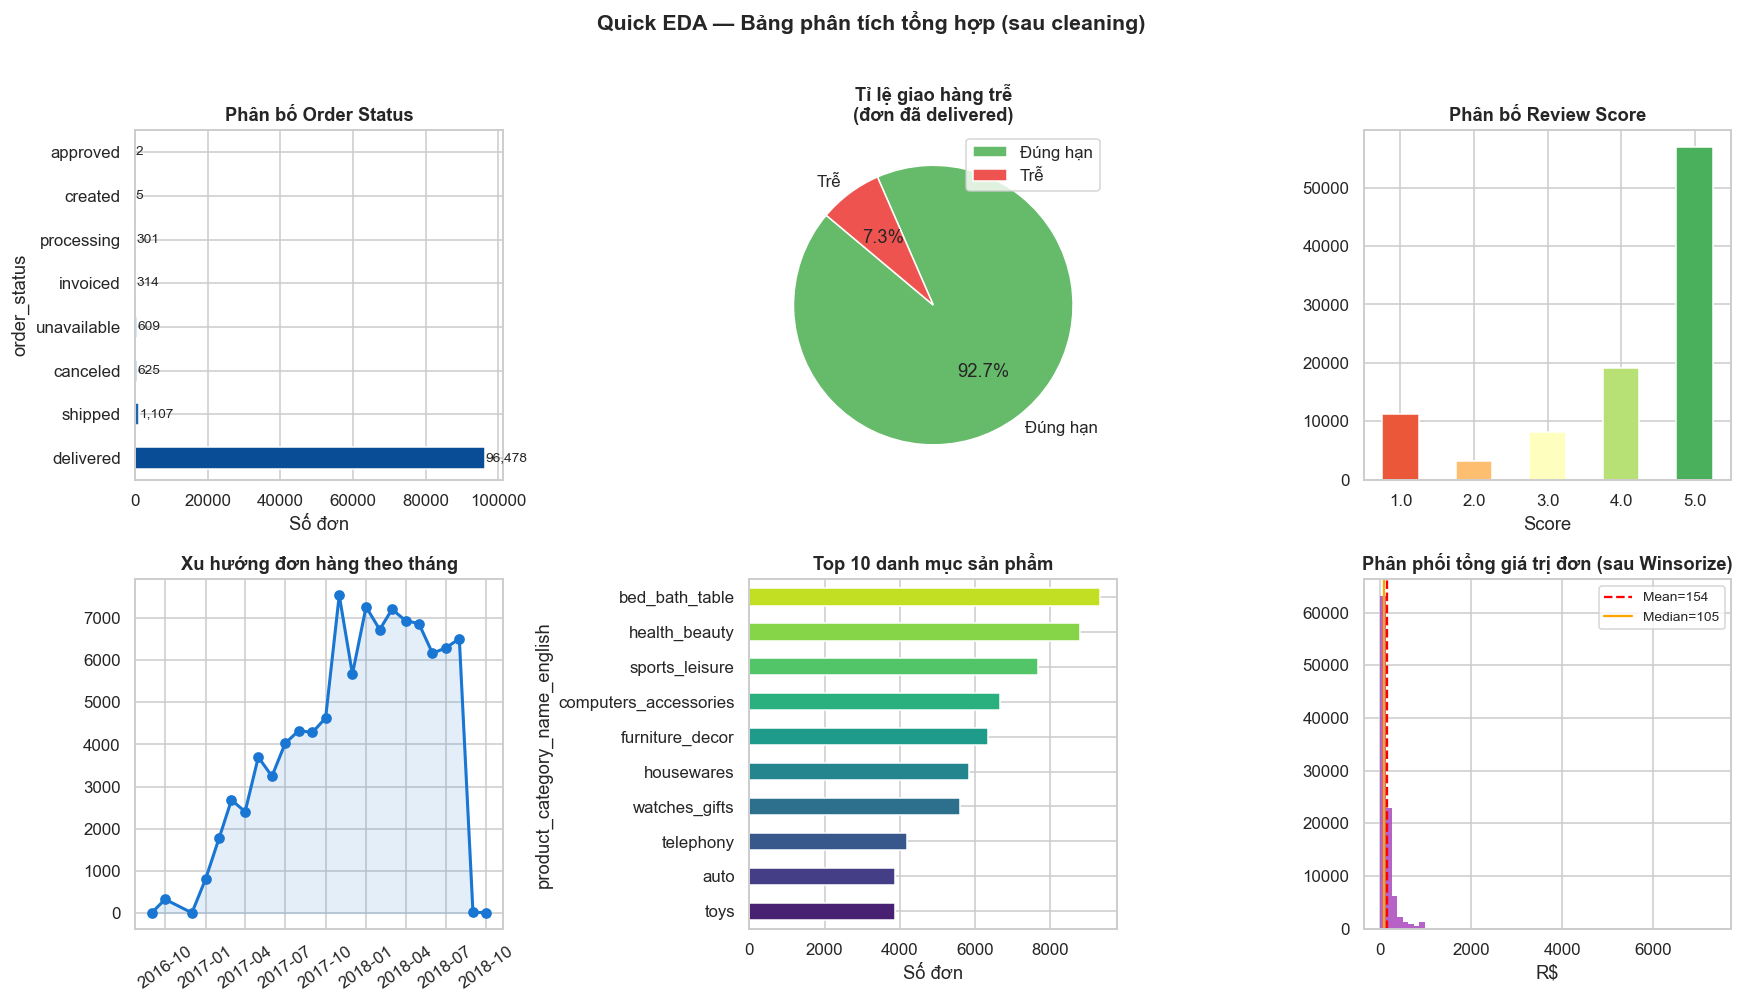

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Order status
ax = axes[0][0]
vc = df_anal["order_status"].value_counts()
vc.plot(kind="barh", ax=ax, color=sns.color_palette("Blues_r", len(vc)))
ax.set_title("Phân bố Order Status", fontweight="bold")
ax.set_xlabel("Số đơn")
for i, v in enumerate(vc.values):
    ax.text(v + 100, i, f"{v:,}", va="center", fontsize=9)

# 2. Tỉ lệ giao hàng trễ
ax = axes[0][1]
late = df_anal["is_late_delivery"].value_counts().rename({0: "Đúng hạn", 1: "Trễ"})
late.plot(kind="pie", ax=ax, autopct="%1.1f%%",
          colors=["#66BB6A", "#EF5350"], startangle=140, legend=True)
ax.set_title("Tỉ lệ giao hàng trễ\n(đơn đã delivered)", fontweight="bold")
ax.set_ylabel("")

# 3. Review score
ax = axes[0][2]
df_anal["avg_review_score"].round().value_counts().sort_index().plot(
    kind="bar", ax=ax, color=sns.color_palette("RdYlGn", 5))
ax.set_title("Phân bố Review Score", fontweight="bold")
ax.set_xlabel("Score")
ax.tick_params(axis="x", rotation=0)

# 4. Đơn hàng theo tháng
ax = axes[1][0]
monthly = (df_anal.dropna(subset=["purchase_year","purchase_month"])
           .groupby(["purchase_year","purchase_month"]).size().reset_index(name="n"))
monthly["period"] = pd.to_datetime(
    monthly["purchase_year"].astype(str) + "-" +
    monthly["purchase_month"].astype(str).str.zfill(2))
monthly = monthly.sort_values("period")
ax.plot(monthly["period"], monthly["n"], marker="o", linewidth=2, color="#1976D2")
ax.fill_between(monthly["period"], monthly["n"], alpha=0.12, color="#1976D2")
ax.set_title("Xu hướng đơn hàng theo tháng", fontweight="bold")
ax.tick_params(axis="x", rotation=35)

# 5. Top 10 product category
ax = axes[1][1]
top_cat = df_anal["product_category_name_english"].value_counts().head(10)
top_cat[::-1].plot(kind="barh", ax=ax, color=sns.color_palette("viridis", 10))
ax.set_title("Top 10 danh mục sản phẩm", fontweight="bold")
ax.set_xlabel("Số đơn")

# 6. Phân phối giá trị đơn
ax = axes[1][2]
data = df_anal["total_order_value"].dropna()
ax.hist(data, bins=60, color="#AB47BC", edgecolor="none", alpha=0.85)
ax.axvline(data.mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Mean={data.mean():,.0f}")
ax.axvline(data.median(), color="orange", linestyle="-",  linewidth=1.5, label=f"Median={data.median():,.0f}")
ax.set_title("Phân phối tổng giá trị đơn (sau Winsorize)", fontweight="bold")
ax.set_xlabel("R$")
ax.legend(fontsize=9)

plt.suptitle("Quick EDA — Bảng phân tích tổng hợp (sau cleaning)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 8. Lưu output

>  File `olist_analytical_table.csv` là **input duy nhất** cho:
> - Data Analysis with SQL
> - Data Visualization
> - Regression / ML Analysis

In [80]:
OUTPUT = "olist_analytical_table.csv"
df_anal.to_csv(OUTPUT, index=False)

print("=" * 60)
print(f"✅ Đã lưu: '{OUTPUT}'")
print(f"   Rows : {df_anal.shape[0]:,}")
print(f"   Cols : {df_anal.shape[1]}")
print("=" * 60)
print("\n Danh sách cột đầy đủ:")
for i, col in enumerate(df_anal.columns, 1):
    dtype = str(df_anal[col].dtype)
    print(f"  {i:3d}. {col:<45s} [{dtype}]")

✅ Đã lưu: 'olist_analytical_table.csv'
   Rows : 99,441
   Cols : 49

 Danh sách cột đầy đủ:
    1. order_id                                      [object]
    2. customer_id                                   [object]
    3. customer_unique_id                            [object]
    4. customer_city                                 [object]
    5. customer_state                                [object]
    6. order_status                                  [object]
    7. order_purchase_timestamp                      [datetime64[ns]]
    8. order_approved_at                             [datetime64[ns]]
    9. order_delivered_carrier_date                  [datetime64[ns]]
   10. order_delivered_customer_date                 [datetime64[ns]]
   11. order_estimated_delivery_date                 [datetime64[ns]]
   12. purchase_year                                 [int32]
   13. purchase_month                                [int32]
   14. purchase_quarter                              [int32]
  

## 9. Tóm tắt pipeline

```
RAW DATA (8 CSV)
      │
      ▼
[Notebook này]
  ├─ 1. Data Loading
  ├─ 2. Data Understanding    (ER diagram, head)
  ├─ 3. EDA Sơ bộ             ← TRƯỚC CLEANING
  │       ├─ 3.1 df.info()    (shape, dtype, non-null)
  │       ├─ 3.2 df.describe() (thống kê mô tả)
  │       ├─ 3.3 value_counts  (phân phối categorical)
  │       ├─ 3.4 Missing %
  │       ├─ 3.5 Duplicates
  │       ├─ 3.6 Referential integrity
  │       ├─ 3.7 Outlier boxplot (TRƯỚC)
  │       └─ 3.8 Outlier stats table
  ├─ 4. Data Cleaning          ← SAU EDA
  │       ├─ 4.1 Datetime conversion
  │       ├─ 4.2 String normalization
  │       ├─ 4.3 Missing values (chỉ loại "dữ liệu xấu")
  │       ├─ 4.4 Winsorization (1%–99% cap + flags)
  │       └─ 4.5 Histogram SAU winsorize
  ├─ 5. Feature Engineering
  ├─ 6. Build Analytical Table (join 8 bảng → 1)
  ├─ 7. EDA Kiểm tra lại       ← SAU CLEANING
  │       ├─ 7.1 describe() bảng tổng hợp
  │       ├─ 7.2 Missing classification
  │       └─ 7.3 Quick visualization
  └─ 8. Export → olist_analytical_table.csv
              │
    ┌─────────┼──────────┐
    ▼         ▼          ▼
  SQL        Viz     Regression
```